## Hotel Booking Data Analysis

In [2]:
import pandas as pd
import numpy as np                 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')       

In [3]:
# Reading the dataset
df=pd.read_csv('Hotel_bookings_final.csv')
df.sample(10)

,customer_id,property_id,city,star_rating,booking_date,check_in_date,check_out_date,room_type,num_rooms_booked,stay_type,...,selling_price,payment_method,refund_status,refund_amount,channel_of_booking,booking_status,travel_date,cashback,coupon_redeem,Coupon USed?
26887,426,5,Dallas,4,2025-03-20,2025-05-10,2025-05-16,Deluxe,1,Leisure,...,43432,PayPal,Yes,452.764570,Android,Confirmed,2024-09-11,0.000000,0.0,No
23792,59,5,San Francisco,2,2025-02-07,NaN,NaN,Deluxe,1,Business,...,9555,PayPal,Yes,0.000000,Web,Cancelled,2024-08-21,0.000000,0.0,No
12997,49,5,Seattle,2,2024-09-18,2024-10-28,2024-10-31,Suite,2,Leisure,...,14088,Bank Transfer,No,0.000000,Web,Confirmed,2024-05-26,0.000000,0.0,No
27499,354,7,Las Vegas,3,2025-03-28,2025-05-21,2025-05-22,Standard,1,Leisure,...,21960,Bank Transfer,No,0.000000,Web,Confirmed,2024-09-02,0.000000,0.0,No
27441,267,1,Miami,4,2025-03-27,2025-05-24,2025-05-31,Deluxe,1,Leisure,...,43246,Debit Card,No,0.000000,Android,Confirmed,2024-09-14,4.527980,0.0,No
28341,497,5,Boston,2,2025-04-08,2025-04-23,2025-04-24,Standard,1,Leisure,...,22338,Credit Card,Yes,156.766515,Android,Confirmed,2024-09-02,0.000000,0.0,No
11321,279,3,Dallas,5,2024-08-27,2024-10-23,2024-10-29,Standard,1,Leisure,...,9276,Bank Transfer,No,0.000000,Web,Cancelled,2024-05-18,9.978861,0.0,No
6169,29,1,Chicago,4,2024-06-21,2024-07-16,2024-07-21,Deluxe,2,Leisure,...,38909,Debit Card,Yes,805.399663,Android,Confirmed,2024-04-18,11.710506,0.0,No
22419,471,7,New York,3,2025-01-20,2025-02-08,2025-02-12,Suite,2,Business,...,46490,PayPal,Yes,818.872077,Android,Confirmed,2024-08-01,0.000000,0.0,No
14968,131,1,New York,2,2024-10-14,2024-12-09,2024-12-12,Standard,1,Leisure,...,40713,Credit Card,No,0.000000,iOS,Failed,2024-06-24,1.287120,0.0,No


### Data Exploration

In [4]:
df.shape

(30000, 24)

In [5]:
columns=list(df.columns)
columns

['customer_id',
 'property_id',
 'city',
 'star_rating',
 'booking_date',
 'check_in_date',
 'check_out_date',
 'room_type',
 'num_rooms_booked',
 'stay_type',
 'booking_channel',
 'booking_value',
 'costprice',
 'markup',
 'selling_price',
 'payment_method',
 'refund_status',
 'refund_amount',
 'channel_of_booking',
 'booking_status',
 'travel_date',
 'cashback',
 'coupon_redeem',
 'Coupon USed?']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         30000 non-null  int64  
 1   property_id         30000 non-null  int64  
 2   city                30000 non-null  str    
 3   star_rating         30000 non-null  int64  
 4   booking_date        30000 non-null  str    
 5   check_in_date       24532 non-null  str    
 6   check_out_date      24532 non-null  str    
 7   room_type           30000 non-null  str    
 8   num_rooms_booked    30000 non-null  int64  
 9   stay_type           30000 non-null  str    
 10  booking_channel     30000 non-null  str    
 11  booking_value       30000 non-null  float64
 12  costprice           30000 non-null  int64  
 13  markup              30000 non-null  int64  
 14  selling_price       30000 non-null  int64  
 15  payment_method      30000 non-null  str    
 16  refund_status  

Here, We can see that 5,468 custmer's check_in_date and check_out_date are missing and also all date columns are in string datatypes

### Data Cleaning and Transform

We don't have to remove or replace the null values appired in check_in_date and check_out_date because after cross-Checking with booking_status, every single missing check-in/check-out corresponded to a Cancelled or Failed booking. A guest who never checked in logically has no check-in date. Dropping those rows would have removed 18% of the data and distorted the cancellation analysis.

In [7]:
#Converting to the date time strings to datetime
df['booking_date'] = pd.to_datetime(df['booking_date'])
df['travel_date']  = pd.to_datetime(df['travel_date'])
df['check_in_date'] = pd.to_datetime(df['check_in_date'])
df['check_out_date']  = pd.to_datetime(df['check_out_date'])

In [8]:
# Extracting the necessary feature
df['booking_month']      = df['booking_date'].dt.month
df['booking_month_name'] = df['booking_date'].dt.strftime('%b')
df['travel_month']       = df['travel_date'].dt.month
df['lead_days']          = (df['travel_date'] - df['booking_date']).dt.days

In [9]:
#Statistical understanding
df[['booking_value','selling_price','markup','num_rooms_booked']].describe().round(2)

,booking_value,selling_price,markup,num_rooms_booked
count,30000.00,30000.00,30000.00,30000.00
mean,25080.53,29504.82,6963.32,1.35
std,11587.37,12119.63,2860.11,0.57
min,1279.77,5003.00,1181.00,1.00
25%,15922.71,19750.50,4661.75,1.00
50%,24736.14,29752.50,7021.50,1.00
75%,33570.00,39826.00,9399.00,2.00
max,67764.46,50000.00,11800.00,3.00


### OBSERVATIONS & TRENDS 

#### Booking Status Distribution 

In [10]:
book_stat= df['booking_status'].value_counts()
print("\nDistribution according to the count")
print(book_stat)
print("\nPercentage:")
print((book_stat / len(df) * 100).round(1))
cancel=round((df['booking_status'] == 'Cancelled').mean() * 100, 2)
print("\nCancellation Rate:",cancel, "%")



Distribution according to the count
booking_status
Confirmed    21672
Cancelled     6070
Failed        2258
Name: count, dtype: int64

Percentage:
booking_status
Confirmed    72.2
Cancelled    20.2
Failed        7.5
Name: count, dtype: float64

Cancellation Rate: 20.23 %


#### Booking Patterns by Channel

In [11]:
#Channel wise distribution
ch_summary = df.groupby('booking_channel').agg(
    bookings=('booking_status','count'),
    confirmed=('booking_status', lambda x: (x=='Confirmed').sum()),
    cancelled=('booking_status', lambda x: (x=='Cancelled').sum()),
    cancel_rate=('booking_status', lambda x: round((x=='Cancelled').mean()*100,2)),
    avg_value=('booking_value', lambda x: round(x.mean(),2)),
    total_revenue=('booking_value', lambda x: round(x[df.loc[x.index,'booking_status']=='Confirmed'].sum(),0))
).reset_index()
print(ch_summary.to_string(index=False))

booking_channel  bookings  confirmed  cancelled  cancel_rate  avg_value  total_revenue
     Mobile App     12009       8111       2589        21.56   21351.29    176325347.0
   Travel Agent      2990       1979        835        27.93   24453.97     48225945.0
            Web     15001      11582       2646        17.64   28190.84    326252208.0


#### BOOKING PATTERNS BY ROOM TYPE

In [12]:
room_type = df.groupby('room_type').agg(
    count=('booking_status','count'),
    cancel_rate=('booking_status', lambda x: round((x=='Cancelled').mean()*100,2)),
    avg_value=('booking_value','mean')
).round(2)
print(room_type.to_string())


           count  cancel_rate  avg_value
room_type                               
Deluxe     10478        16.02   25004.57
Standard   16552        23.30   25146.97
Suite       2970        17.98   24978.21


#### BOOKING PATTERNS BY RATING

In [13]:
rating_summ = df.groupby('star_rating').agg(
    count=('booking_status','count'),
    cancel_rate=('booking_status', lambda x: round((x=='Cancelled').mean()*100,2)),
    avg_value=('booking_value','mean'),
    avg_markup=('markup','mean')
).round(2)
print(rating_summ.to_string())


             count  cancel_rate  avg_value  avg_markup
star_rating                                           
2             2995        19.77   24855.82     6973.19
3            10460        20.20   25209.57     6997.47
4            12034        19.99   25010.62     6959.01
5             4511        21.26   25116.97     6889.08


#### Monthly Cancellation Trends

In [14]:
month_dict = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
          7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

In [15]:
month_summ = df.groupby('booking_month').agg(
    total=('booking_status','count'),
    cancelled=('booking_status', lambda x: (x=='Cancelled').sum()),
    avg_value=('booking_value','mean')
).reset_index()
month_summ['cancel_rate'] = (month_summ['cancelled'] / month_summ['total'] * 100).round(2)
month_summ['month_name'] = month_summ['booking_month'].map(month_dict)
print(month_summ[['month_name','total','cancelled','cancel_rate','avg_value']].to_string(index=False))

month_name  total  cancelled  cancel_rate    avg_value
       Jan   2360        559        23.69 23424.240288
       Feb   2132        373        17.50 27806.446412
       Mar   2360        415        17.58 27316.317513
       Apr   4494        733        16.31 25116.494933
       May   2360        408        17.29 23197.152432
       Jun   2284        400        17.51 24202.785705
       Jul   2361        716        30.33 25501.593859
       Aug   2360        679        28.77 26064.735975
       Sep   2284        405        17.73 24635.105197
       Oct   2360        410        17.37 24880.617462
       Nov   2285        364        15.93 25753.245326
       Dec   2360        608        25.76 23276.987242


In [16]:
high_cancel = month_summ.nlargest(3, 'cancel_rate')['month_name'].tolist()
print(f"\n Highest cancellation months: {high_cancel}")


 Highest cancellation months: ['Jul', 'Aug', 'Dec']


#### Seasonal Travel Demand Analysis

In [17]:
travel_demand = df.groupby('travel_month').size().reset_index(name='bookings')
travel_demand['month_name'] = travel_demand['travel_month'].map(month_dict)
print(travel_demand[['month_name','bookings']].to_string(index=False))

month_name  bookings
       Jan       339
       Mar      1127
       Apr      3088
       May      3675
       Jun      3919
       Jul      4441
       Aug      5039
       Sep      3787
       Oct      1689
       Nov      1395
       Dec      1501


In [18]:
peak = travel_demand.nlargest(3,'bookings')['month_name'].tolist()
print(f"Peak travel months: {peak}")

Peak travel months: ['Aug', 'Jul', 'Jun']


#### CANCELLATION BEHAVIOR ANALYSIS

#### Payment method

In [19]:
pay_type = df.groupby('payment_method')['booking_status'].apply(
    lambda x: round((x=='Cancelled').mean()*100,2)).sort_values(ascending=False)
print(pay_type.to_string())


payment_method
PayPal           20.81
Credit Card      20.57
Debit Card       20.35
Bank Transfer    19.18


##### Cancellation Rate By Stay Type

In [20]:
stay_cr = df.groupby('stay_type')['booking_status'].apply(
    lambda x: round((x=='Cancelled').mean()*100,2))
stay_val = df.groupby('stay_type')['booking_value'].mean().round(2)
print(pd.DataFrame({'cancel_rate':stay_cr,'avg_booking_value':stay_val}).to_string())

           cancel_rate  avg_booking_value
stay_type                                
Business         20.05           25144.42
Leisure          20.35           25038.58


##### City Wise Cancellation

In [21]:
#Cancellation Rate By City
city_summ = df.groupby('city')['booking_status'].apply(
    lambda x: round((x=='Cancelled').mean()*100,2)).sort_values(ascending=False)
print(city_summ.to_string())

city
Los Angeles      20.92
Chicago          20.53
Orlando          20.50
Miami            20.31
New York         20.31
Las Vegas        20.26
Boston           20.19
Dallas           20.00
San Francisco    19.89
Seattle          19.39


##### Cancellation Rate By Coupon usage

In [22]:
coupon_use = df.groupby('Coupon USed?').agg(
    count=('booking_value','count'),
    cancel_rate=('booking_status', lambda x: round((x=='Cancelled').mean()*100,2)),
    avg_value=('booking_value','mean')
).round(2)
print(coupon_use.to_string())

              count  cancel_rate  avg_value
Coupon USed?                               
No            23807        20.09   25167.90
Yes            6193        20.80   24744.65


### Visualization

In [23]:
#Choosing Colors
colors = ['#4CAF50', '#FF5252', '#2196F3']

Booking Status & Channel Analysis

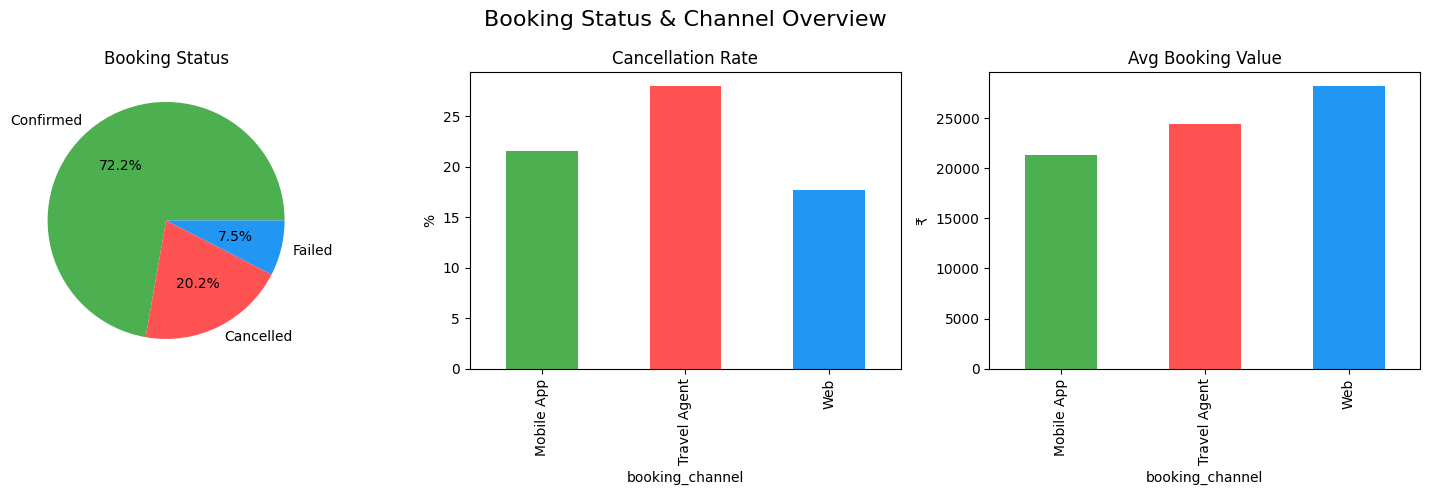

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Booking Status & Channel Overview", fontsize=16)
# 1. Booking Status Pie Chart
df['booking_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=colors,
    ax=ax[0]
)
ax[0].set_ylabel('')
ax[0].set_title("Booking Status")
# 2. Cancellation Rate by Channel
cancel_rate = (
    df.assign(cancelled=df['booking_status'] == 'Cancelled')
      .groupby('booking_channel')['cancelled']
      .mean() * 100
)
cancel_rate.plot(kind='bar', color=colors, ax=ax[1])
ax[1].set_title("Cancellation Rate")
ax[1].set_ylabel("%")
# 3. Average Booking Value by Channel
avg_value = df.groupby('booking_channel')['booking_value'].mean()
avg_value.plot(kind='bar', color=colors, ax=ax[2])
ax[2].set_title("Avg Booking Value")
ax[2].set_ylabel("₹")

plt.tight_layout()
plt.show()

Monthly Booking Trends

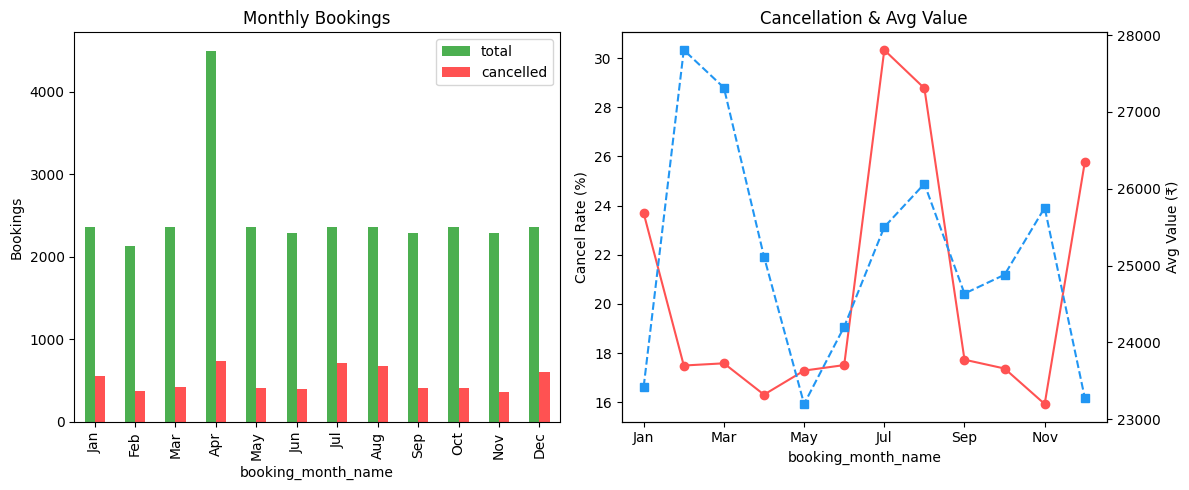

In [31]:
# Monthly Summary
months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

monthly = df.groupby('booking_month_name').agg(
    total=('booking_status', 'count'),
    cancelled=('booking_status', lambda x: (x == 'Cancelled').sum()),
    avg_value=('booking_value', 'mean')
)

monthly['cancel_rate'] = monthly['cancelled'] / monthly['total'] * 100
monthly = monthly.reindex(months)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Monthly bookings
monthly[['total', 'cancelled']].plot(
    kind='bar',
    color=[colors[0], colors[1]],
    ax=ax[0]
)

ax[0].set_title('Monthly Bookings')
ax[0].set_ylabel('Bookings')

# Cancellation rate + Avg value
monthly['cancel_rate'].plot(
    kind='line',
    marker='o',
    color=colors[1],
    ax=ax[1]
)

ax2 = ax[1].twinx()

monthly['avg_value'].plot(
    kind='line',
    marker='s',
    linestyle='--',
    color=colors[2],
    ax=ax2
)

ax[1].set_title('Cancellation & Avg Value')
ax[1].set_ylabel('Cancel Rate (%)')
ax2.set_ylabel('Avg Value (₹)')

plt.tight_layout()
plt.show()

Room Type & Star Rating

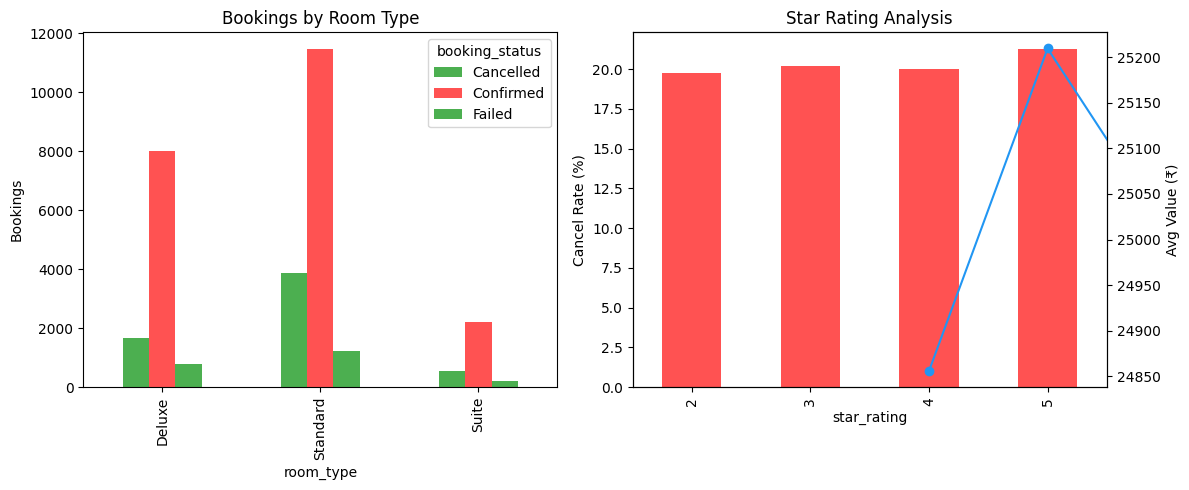

In [32]:
# Room type and Star Rating
fig, ax = plt.subplots(1, 2, figsize=(12,5))
# Room Type Analysis
pd.crosstab(df['room_type'], df['booking_status']).plot(
    kind='bar',
    color=[colors[0], colors[1]],
    ax=ax[0]
)

ax[0].set_title('Bookings by Room Type')
ax[0].set_ylabel('Bookings')

# Star Rating Analysis
df.assign(cancelled=df['booking_status'] == 'Cancelled') \
.groupby('star_rating')['cancelled'] \
.mean() \
.mul(100) \
.plot(
    kind='bar',
    color=colors[1],
    ax=ax[1]
)
ax2 = ax[1].twinx()
df.groupby('star_rating')['booking_value'] \
.mean() \
.plot(
    kind='line',
    marker='o',
    color=colors[2],
    ax=ax2
)
ax[1].set_title('Star Rating Analysis')
ax[1].set_ylabel('Cancel Rate (%)')
ax2.set_ylabel('Avg Value (₹)')
plt.tight_layout()
plt.show()

Seasonal Demand & Revenue

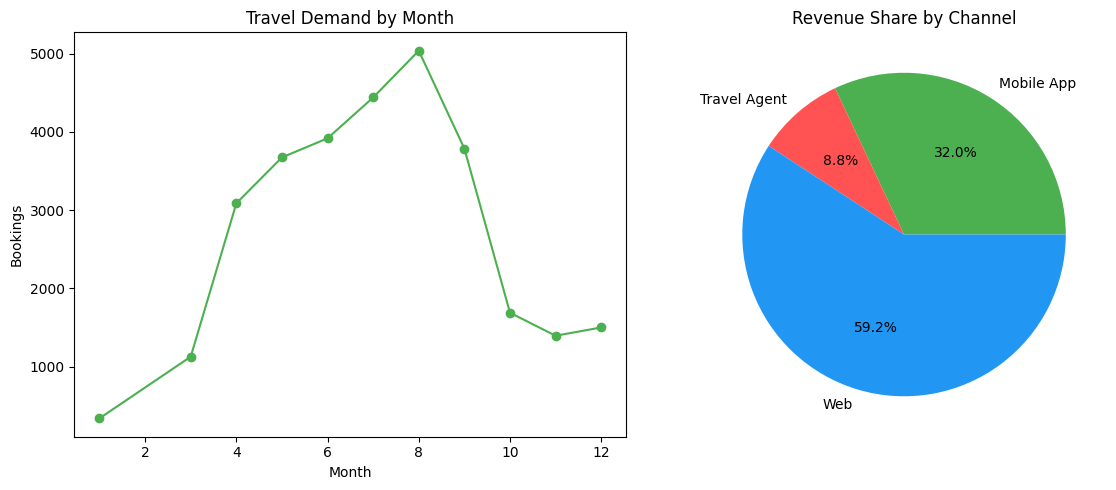

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))
# Travel demand by month
df['travel_month'].value_counts().sort_index().plot(
    kind='line',
    marker='o',
    color=colors[0],
    ax=ax[0]
)
ax[0].set_title('Travel Demand by Month')
ax[0].set_xlabel('Month')
ax[0].set_ylabel('Bookings')
# Revenue share by channel
df[df['booking_status'] == 'Confirmed'] \
.groupby('booking_channel')['booking_value'] \
.sum() \
.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=[colors[0], colors[1], colors[2]],
    ax=ax[1]
)
ax[1].set_ylabel('')
ax[1].set_title('Revenue Share by Channel')

plt.tight_layout()
plt.show()

Cancellation Behavior 

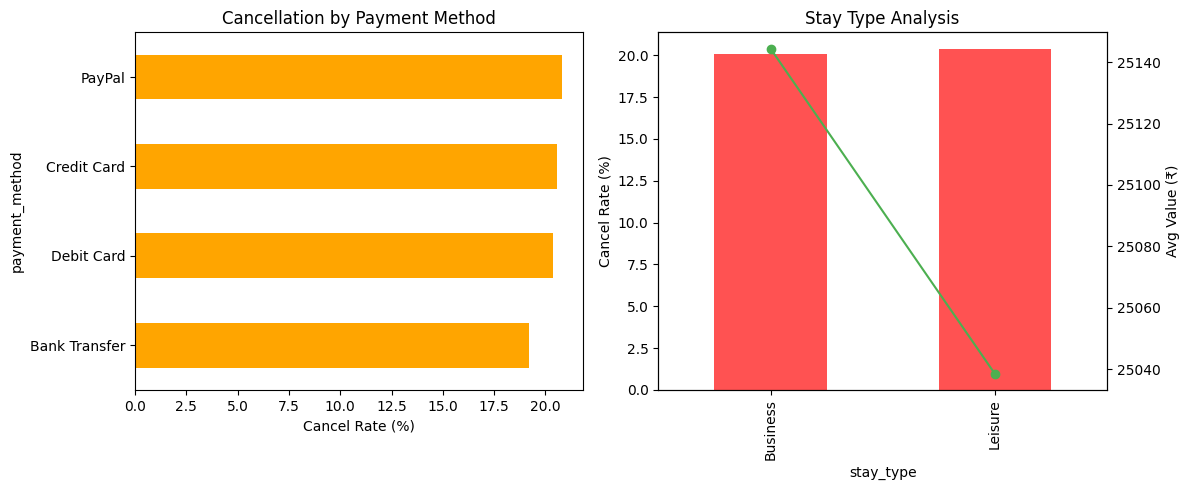

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))
# Payment Method Analysis
df.assign(cancelled=df['booking_status'] == 'Cancelled') \
.groupby('payment_method')['cancelled'] \
.mean() \
.mul(100) \
.sort_values() \
.plot(
    kind='barh',
    color='orange',
    ax=ax[0]
)

ax[0].set_title('Cancellation by Payment Method')
ax[0].set_xlabel('Cancel Rate (%)')

# Stay Type Analysis
df.assign(cancelled=df['booking_status'] == 'Cancelled') \
.groupby('stay_type')['cancelled'] \
.mean() \
.mul(100) \
.plot(
    kind='bar',
    color=colors[1],
    ax=ax[1]
)

ax2 = ax[1].twinx()

df.groupby('stay_type')['booking_value'] \
.mean() \
.plot(
    kind='line',
    marker='o',
    color=colors[0],
    ax=ax2
)
ax[1].set_title('Stay Type Analysis')
ax[1].set_ylabel('Cancel Rate (%)')
ax2.set_ylabel('Avg Value (₹)')

plt.tight_layout()
plt.show()

### ROOT CAUSE ANALYSIS SUMMARY

##### ROOT CAUSE: CANCELLATION BEHAVIOR PATTERNS
1. Travel Agent channel experiences maximum cancellations (27.93%)-Bulk
   booking through this channel might lead to speculation and cancellation
   of remaining rooms.
2. Months showing maximum cancellations: January (23.69%), July (30.33%),
   August (28.77%) and December (25.76%) – Last-minute plans and overbooking
   during peak seasons may cause cancellations.
3. Standard Rooms show maximum cancellations (23.3%) while Deluxe is 
   less at 16% – More budget-oriented bookings tend to cancel for better 
   rates.
4. PayPal channel shows slightly more cancellations (20.81%) due to 
   ease of transaction reversal and less resistance.

##### ROOT CAUSE: CHANNEL PERFORMANCE
1. Web Channel shows maximum average value (₹28,191) – Desktop booking 
   tends to be planned and high-intent.
2. Mobile App channel has minimum average value (₹21,351) – Bookings are
   impulsive and small screen size might lead to faster bookings.
3. Travel Agent channel has decent average value but maximum cancellations.

##### ROOT CAUSE: SEASONALITY PATTERN
1. Peak travel demand: August > July > June > September – Summer holidays
   result in 5,039 & 4,441 bookings respectively.
2. April shows spike in booking for future summers – bookings in next
   3-4 months before summer vacation.
3. Travel demand is low in January & October-December periods except
   for Christmas.

##### BUSINESS RECOMMENDATIONS

#### 1. Cancellation Reduction Strategy
- Apply non-refundable or partially refundable pricing models with 5–10% discounts to secure bookings.
- Send personalized reminders 30, 14, and 7 days before check-in to reduce no-shows.
- Enforce deposit payments for bulk bookings from travel agents.
- Apply dynamic cancellation policies during peak cancellation months like Jul, Aug, and Dec.

#### 2. Increased Profitability Strategy
- Promote Deluxe room upgrades to Standard room customers through mobile app notifications and website offers.
- Increase the market share of Web channel customers, as they generate the highest average revenue per booking.
- Reward loyalty members and confirmed customers with cashback offers and discounts to encourage repeat bookings.
- Promote 5-star property packages for corporate travelers and honeymoon customers.

#### 3. Price & Promotion Strategy
- Implement dynamic pricing based on demand:
  - Higher prices during Jun–Aug
  - Discounted prices during Jan and Nov
- Target business travelers with mid-week offers and corporate rate cards.
- Use selective coupon promotions since coupon users generate lower booking value.
- Promote mobile app exclusive deals to increase booking value by approximately ₹6,800.